# WeatherForYnov — Analyse exploratoire (SAMIR)

**Hackathon YNOV — Sujet 2 : Prévisions météorologiques**

Ce notebook construit puis explore le jeu de données **`src/data/processed/climat_source.csv`**, qui constitue la **source de vérité** pour le feature engineering et le ML.

## Schéma de `climat_source.csv`
- **Granularité** : station météo (`NUM_POSTE`) × mois
- **Période** : années **> 2000** (2001–2025), séries **complètes** (12 mois / station / année)
- **Qualité** : codes Météo-France **Q0, Q1, Q9** uniquement (0 = manquant, 1 = valide, 9 = douteux)
- **Géographie** : département + région fusionnés via `referentiel_geo_departements.csv`

## Organisation du notebook
1. **Partie A** — Construction du fichier source depuis les CSV MENSQ bruts
2. **Partie B** — Exploration à partir de `climat_source.csv` (toute l'analyse s'appuie sur ce fichier)

## 1. Configuration et imports

In [41]:
from pathlib import Path
import re
import gc
import warnings
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "src" / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

GEO_PATH = DATA_DIR / "referentiel_geo_departements.csv"
SOURCE_CSV = PROCESSED_DIR / "climat_source.csv"

# Reconstruire le fichier depuis MENSQ (True = régénérer ; False = EDA sur fichier existant)
REBUILD_SOURCE = False

# Codes qualité Météo-France conservés (cf. descriptif MENSQ)
ALLOWED_Q_CODES = {0, 1, 9}  # 0 = manquant, 1 = valide, 9 = douteux

# Schéma officiel de climat_source.csv
ID_COLS = [
    "NUM_POSTE", "nom_station", "lat", "lon", "alti",
    "code_departement", "nom_departement", "code_region", "nom_region",
]
TIME_COLS = ["annee", "mois", "date"]
METEO_COLS = [
    "precipitations_mm", "temp_max", "temp_min", "temp_moy_jour",
    "temp_moy_mensuelle", "humidite", "pression_mer", "vent_moyen",
    "insolation", "rayonnement_global", "evapotranspiration", "rafale_max",
]
SOURCE_COLUMNS = ID_COLS + TIME_COLS + METEO_COLS

VARIABLES = {
    "precipitations_mm": ("RR", "QRR"),
    "temp_max": ("TX", "QTX"),
    "temp_min": ("TN", "QTN"),
    "temp_moy_jour": ("TM", "QTM"),
    "temp_moy_mensuelle": ("TMM", "QTMM"),
    "humidite": ("UMM", "QUMM"),
    "pression_mer": ("PMERM", "QPMERM"),
    "vent_moyen": ("FFM", "QFFM"),
    "insolation": ("INST", "QINST"),
    "rayonnement_global": ("GLOT", "QGLOT"),
    "evapotranspiration": ("ETP", "QETP"),
    "rafale_max": ("FXIAB", "QFXIAB"),
}

print(f"Racine projet : {ROOT}")
print(f"Source de vérité : {SOURCE_CSV}")

Racine projet : c:\Users\MASTER DATA&IA\Desktop\YNOV\Hackathon
Source de vérité : c:\Users\MASTER DATA&IA\Desktop\YNOV\Hackathon\src\data\processed\climat_source.csv


---
## Partie A — Construction de `climat_source.csv` depuis MENSQ

Convention : `MENSQ_{code_dept}_{periode}.csv` — chaque ligne brute = **station × mois**.

In [42]:
if not REBUILD_SOURCE and SOURCE_CSV.exists():
    print(f"Construction ignorée — {SOURCE_CSV.name} déjà présent (REBUILD_SOURCE=False).")
else:
    USECOLS = ["NUM_POSTE", "NOM_USUEL", "LAT", "LON", "ALTI", "AAAAMM"] + sorted(
        {c for pair in VARIABLES.values() for c in pair}
    )
    STATS_COLS = ["RR", "TX", "TN", "TMM", "UMM", "FFM", "INST"]

    def apply_quality_filter(df: pd.DataFrame, value_col: str, quality_col: str) -> pd.Series:
        """Conserve Q0/Q1/Q9 ; valeur renseignée seulement pour Q1 (valide) et Q9 (douteux)."""
        values = pd.to_numeric(df[value_col], errors="coerce")
        quality = pd.to_numeric(df[quality_col], errors="coerce")
        allowed = quality.isin(ALLOWED_Q_CODES)
        has_value = quality.isin({1, 9})
        return values.where(allowed & has_value)

    def keep_allowed_quality_rows(df: pd.DataFrame) -> pd.DataFrame:
        """Exclut les lignes contenant un code qualité hors {0, 1, 9}."""
        mask = pd.Series(True, index=df.index)
        for _, q_col in VARIABLES.values():
            if q_col not in df.columns:
                continue
            q = pd.to_numeric(df[q_col], errors="coerce")
            mask &= q.isna() | q.isin(ALLOWED_Q_CODES)
        return df[mask].copy()

    files_by_dept: dict[str, list[Path]] = defaultdict(list)
    for path in sorted(DATA_DIR.glob("MENSQ_*_*.csv")):
        match = re.match(r"MENSQ_(\d+)_", path.name)
        if match:
            files_by_dept[match.group(1).zfill(2)].append(path)

    print(f"{sum(len(v) for v in files_by_dept.values())} fichiers — {len(files_by_dept)} départements")

    station_monthly_parts = []
    sample_raw = None
    n_rows = 0
    stations: set[str] = set()
    annee_min, annee_max = 10**9, 0
    q_counts = {q: Counter() for _, q in VARIABLES.values()}
    tmm_before = 0
    tmm_after = 0
    raw_stats = {col: {"n": 0, "sum": 0.0, "min": np.inf, "max": -np.inf} for col in STATS_COLS}

    for dept, paths in sorted(files_by_dept.items()):
        parts = [pd.read_csv(p, sep=";", usecols=USECOLS) for p in paths]
        chunk = pd.concat(parts, ignore_index=True)
        del parts

        chunk["code_departement"] = dept
        chunk["annee"] = chunk["AAAAMM"].astype(str).str[:4].astype(int)
        chunk["mois"] = chunk["AAAAMM"].astype(str).str[4:6].astype(int)

        if sample_raw is None:
            sample_raw = chunk.head(3).copy()

        n_rows += len(chunk)
        stations.update(chunk["NUM_POSTE"].dropna().astype(str).unique())
        annee_min = min(annee_min, int(chunk["annee"].min()))
        annee_max = max(annee_max, int(chunk["annee"].max()))

        tmm_before += pd.to_numeric(chunk["TMM"], errors="coerce").notna().sum()
        chunk = keep_allowed_quality_rows(chunk)

        for _, q_col in VARIABLES.values():
            q = pd.to_numeric(chunk[q_col], errors="coerce").dropna().astype(int)
            q_counts[q_col].update(q.tolist())

        for col in STATS_COLS:
            s = pd.to_numeric(chunk[col], errors="coerce").dropna()
            if s.empty:
                continue
            raw_stats[col]["n"] += len(s)
            raw_stats[col]["sum"] += float(s.sum())
            raw_stats[col]["min"] = min(raw_stats[col]["min"], float(s.min()))
            raw_stats[col]["max"] = max(raw_stats[col]["max"], float(s.max()))

        station_meta = chunk.groupby("NUM_POSTE", as_index=False).agg(
            nom_station=("NOM_USUEL", "first"),
            lat=("LAT", "first"),
            lon=("LON", "first"),
            alti=("ALTI", "first"),
        )

        clean = chunk[["NUM_POSTE", "code_departement", "annee", "mois"]].copy()
        for target, (value_col, quality_col) in VARIABLES.items():
            clean[target] = apply_quality_filter(chunk, value_col, quality_col)
        tmm_after += clean["temp_moy_mensuelle"].notna().sum()

        clean = clean.merge(station_meta, on="NUM_POSTE", how="left")
        clean = clean.drop_duplicates(subset=["NUM_POSTE", "annee", "mois"], keep="last")
        station_monthly_parts.append(clean)
        del chunk, clean, station_meta
        gc.collect()

    station_monthly = pd.concat(station_monthly_parts, ignore_index=True)
    station_monthly["date"] = pd.to_datetime(
        {"year": station_monthly["annee"], "month": station_monthly["mois"], "day": 1}
    )
    station_monthly["NUM_POSTE"] = station_monthly["NUM_POSTE"].astype(str).str.zfill(8)
    del station_monthly_parts

    load_summary = pd.Series(
        {
            "observations_brutes": n_rows,
            "stations": len(stations),
            "departements": len(files_by_dept),
            "annee_min": annee_min,
            "annee_max": annee_max,
            "lignes_station_mois": len(station_monthly),
        },
        name="valeur",
    )
    q_distribution = pd.DataFrame(
        {q_col: dict(counter) for q_col, counter in q_counts.items()}
    ).fillna(0).astype(int)

    print(load_summary.to_string())
    print(f"\nTMM avec valeur (Q1 ou Q9) : {tmm_after:,} / {tmm_before:,}")

Construction ignorée — climat_source.csv déjà présent (REBUILD_SOURCE=False).


### A.1 Données brutes — aperçu avant filtrage final

In [43]:
if REBUILD_SOURCE or not SOURCE_CSV.exists():
    print("=== Synthèse du chargement MENSQ ===")
    display(load_summary.to_frame())

    print("\nAperçu brut :")
    display(sample_raw[["NUM_POSTE", "NOM_USUEL", "AAAAMM", "RR", "QRR", "TMM", "QTMM", "TX", "TN", "UMM"]])

    print("\nDistribution des codes qualité (Q0 / Q1 / Q9) :")
    display(q_distribution)

    raw_describe = pd.DataFrame(raw_stats).T
    raw_describe["mean"] = raw_describe["sum"] / raw_describe["n"]
    raw_describe = raw_describe.rename(columns={"n": "count"})[["count", "mean", "min", "max"]]
    print("\nStatistiques brutes (avant filtrage qualité) :")
    display(raw_describe.round(2))

### A.2 Fusion référentiel géographique + filtres finaux

| Filtre | Règle |
|--------|-------|
| Qualité | **Q0, Q1, Q9** uniquement — valeurs conservées pour Q1 et Q9 |
| Période | `annee > 2000` |
| Série complète | 12 mois / `NUM_POSTE` / année, `temp_moy_mensuelle` renseignée chaque mois |

In [44]:
if REBUILD_SOURCE or not SOURCE_CSV.exists():
    geo = pd.read_csv(GEO_PATH, sep=";")
    geo["code_departement"] = geo["code_departement"].astype(str).str.zfill(2)

    station_monthly = station_monthly.merge(geo, on="code_departement", how="left")

    post2000 = station_monthly[station_monthly["annee"] > 2000].copy()
    complete_pairs = (
        post2000.groupby(["NUM_POSTE", "annee"])
        .filter(lambda g: g["mois"].nunique() == 12 and g["temp_moy_mensuelle"].notna().all())
        [["NUM_POSTE", "annee"]]
        .drop_duplicates()
    )

    built_df = post2000.merge(complete_pairs, on=["NUM_POSTE", "annee"], how="inner")
    built_df = built_df[SOURCE_COLUMNS].sort_values(["NUM_POSTE", "annee", "mois"]).reset_index(drop=True)
    built_df["code_departement"] = built_df["code_departement"].astype(str).str.zfill(2)

    built_df.to_csv(SOURCE_CSV, index=False)

    print(f"Fichier écrit : {SOURCE_CSV}")
    print(f"Dimensions : {built_df.shape[0]:,} lignes × {built_df.shape[1]} colonnes")
    print(f"Période : {built_df['annee'].min()} – {built_df['annee'].max()}")
    print(f"Stations : {built_df['NUM_POSTE'].nunique():,} | Départements : {built_df['code_departement'].nunique()}")
    built_df.head(3)

---
## Partie B — Exploration à partir de `climat_source.csv`

Toute l'analyse ci-dessous charge **`climat_source.csv`**, source de vérité partagée avec le notebook ML et l'application.

In [45]:
df = pd.read_csv(SOURCE_CSV, parse_dates=["date"])
df["NUM_POSTE"] = df["NUM_POSTE"].astype(str).str.zfill(8)
df["code_departement"] = df["code_departement"].astype(str).str.zfill(2)

# Vérification du schéma
missing_cols = set(SOURCE_COLUMNS) - set(df.columns)
extra_cols = set(df.columns) - set(SOURCE_COLUMNS)
assert not missing_cols, f"Colonnes manquantes dans climat_source.csv : {missing_cols}"
if extra_cols:
    print(f"Colonnes supplémentaires ignorées : {extra_cols}")

df = df[SOURCE_COLUMNS].copy()

# Features dérivées pour l'EDA (non exportées dans climat_source.csv)
df["saison"] = df["mois"].map({
    12: "hiver", 1: "hiver", 2: "hiver",
    3: "printemps", 4: "printemps", 5: "printemps",
    6: "ete", 7: "ete", 8: "ete",
    9: "automne", 10: "automne", 11: "automne",
})
df["decennie"] = (df["annee"] // 10 * 10).astype(str) + "-" + (df["annee"] // 10 * 10 + 9).astype(str)

print("=== climat_source.csv — synthèse ===")
synthese = pd.Series(
    {
        "observations": len(df),
        "stations": df["NUM_POSTE"].nunique(),
        "departements": df["code_departement"].nunique(),
        "regions": df["nom_region"].nunique(),
        "annee_min": int(df["annee"].min()),
        "annee_max": int(df["annee"].max()),
        "mois_par_station_an (attendu=12)": df.groupby(["NUM_POSTE", "annee"])["mois"].nunique().mode().iloc[0],
    },
    name="valeur",
)
display(synthese.to_frame())
df.head(3)

=== climat_source.csv — synthèse ===


,valeur
observations,334500
stations,2336
departements,95
regions,13
annee_min,2001
annee_max,2025
mois_par_station_an (attendu=12),12


,NUM_POSTE,nom_station,lat,lon,alti,code_departement,nom_departement,code_region,nom_region,annee,...,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max,saison,decennie
0,01014002,ARBENT,46.278167,5.669,534,01,Ain,84,Auvergne-Rhône-Alpes,2006,...,-0.8,NaN,NaN,1.2,NaN,NaN,13.0,13.9,hiver,2000-2009
1,01014002,ARBENT,46.278167,5.669,534,01,Ain,84,Auvergne-Rhône-Alpes,2006,...,0.1,NaN,NaN,1.7,NaN,NaN,20.9,17.6,hiver,2000-2009
2,01014002,ARBENT,46.278167,5.669,534,01,Ain,84,Auvergne-Rhône-Alpes,2006,...,4.1,NaN,NaN,2.1,NaN,NaN,42.3,19.5,printemps,2000-2009


### B.0 Taux de complétude sur la période 2001-2025

Calcul du taux de complétude pour les 6 variables clés à partir des **fichiers MENSQ bruts**, filtré sur la période **2001–2025**. Colonnes :
- **non_null** : observations avec valeur non nulle dans les données brutes
- **qualite_ok** : parmi les non_null, celles dont le code qualité est dans {0, 1, 9}
- **taux_remplissage** : `non_null / total_lignes_2001_2025 × 100`

In [ ]:
VARS_CLES = {
    "precipitations_mm": ("RR", "QRR"),
    "temp_moy_mensuelle": ("TMM", "QTMM"),
    "humidite": ("UMM", "QUMM"),
    "vent_moyen": ("FFM", "QFFM"),
    "pression_mer": ("PMERM", "QPMERM"),
    "insolation": ("INST", "QINST"),
}
USECOLS_Q = ["NUM_POSTE", "AAAAMM"] + sorted({c for pair in VARS_CLES.values() for c in pair})

total_rows_2001_2025 = 0
non_null_counts = {v: 0 for v in VARS_CLES}
qualite_ok_counts = {v: 0 for v in VARS_CLES}

for path in sorted(DATA_DIR.glob("MENSQ_*_*.csv")):
    chunk = pd.read_csv(path, sep=";", usecols=lambda c: c in USECOLS_Q)
    annee_serie = chunk["AAAAMM"].astype(str).str[:4].astype(int)
    chunk = chunk[(annee_serie > 2000) & (annee_serie <= 2025)]
    if chunk.empty:
        continue
    total_rows_2001_2025 += len(chunk)
    for var_name, (val_col, q_col) in VARS_CLES.items():
        if val_col in chunk.columns and q_col in chunk.columns:
            vals = pd.to_numeric(chunk[val_col], errors="coerce")
            quals = pd.to_numeric(chunk[q_col], errors="coerce")
            non_null_counts[var_name] += int(vals.notna().sum())
            qualite_ok_counts[var_name] += int((quals.isin(ALLOWED_Q_CODES) & vals.notna()).sum())

completude_2001_2025 = pd.DataFrame([
    {
        "variable": var,
        "non_null": non_null_counts[var],
        "qualite_ok": qualite_ok_counts[var],
        "taux_remplissage": round(non_null_counts[var] / total_rows_2001_2025 * 100, 1),
    }
    for var in VARS_CLES
]).sort_values("taux_remplissage", ascending=False).reset_index(drop=True)

print(f"=== Taux de complétude 2001–2025 ===")
print(f"Total lignes MENSQ (2001–2025) : {total_rows_2001_2025:,}")
display(completude_2001_2025)

### B.1 Statistiques descriptives et taux de remplissage

In [46]:
print("=== Variables météo — describe ===")
display(df[METEO_COLS].describe().round(2))

missing_pct = (df[METEO_COLS].isna().mean() * 100).round(2)
print("\n=== Taux de valeurs manquantes (%) ===")
display(missing_pct.to_frame("% manquants").sort_values("% manquants", ascending=False))

=== Variables météo — describe ===


,precipitations_mm,temp_max,temp_min,temp_moy_jour,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max
count,327429.00,334190.00,334330.00,334094.00,334500.00,67510.00,17023.00,172463.00,36955.00,40852.00,333841.00,170170.00
mean,75.41,16.83,7.23,12.03,11.64,75.80,1017.13,3.18,10046.01,38488.13,75.96,21.06
std,55.74,7.39,5.52,6.34,6.36,9.69,3.99,1.34,4622.81,21034.19,47.54,5.59
min,0.00,-14.20,-20.80,-17.50,-17.90,33.00,1001.50,0.00,0.00,0.00,4.40,4.00
25%,37.60,10.90,3.10,7.10,6.70,69.00,1015.00,2.30,6245.50,17701.75,31.20,17.00
50%,63.60,16.60,7.00,11.80,11.40,76.00,1016.70,3.00,9931.00,38958.00,70.10,20.20
75%,99.10,22.70,11.80,17.30,16.90,83.00,1019.00,3.80,13312.00,57012.25,113.10,24.10
max,1190.90,37.30,25.00,28.60,28.30,99.00,1031.00,16.20,24601.00,86956.00,277.10,67.90



=== Taux de valeurs manquantes (%) ===


,% manquants
pression_mer,94.91
insolation,88.95
rayonnement_global,87.79
humidite,79.82
rafale_max,49.13
vent_moyen,48.44
precipitations_mm,2.11
evapotranspiration,0.20
temp_moy_jour,0.12
temp_max,0.09


### B.2 Distribution et taux de remplissage par décennie

=== Volume par décennie ===


,decennie,nb_lignes,nb_stations,nb_departements
0,2000-2009,64536,1424,95
1,2010-2019,150804,1653,94
2,2020-2029,119160,1906,95



=== Taux de remplissage (%) par décennie ===


,precipitations_mm,temp_max,temp_min,temp_moy_jour,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max
decennie,,,,,,,,,,,,
2000-2009,98.2,99.6,99.9,99.6,100.0,7.3,3.4,57.5,20.2,21.2,99.9,57.2
2010-2019,97.6,100.0,99.9,99.9,100.0,8.0,1.8,56.0,15.8,18.0,99.7,54.6
2020-2029,98.0,100.0,100.0,100.0,100.0,42.5,10.2,42.8,0.0,0.0,99.8,42.7


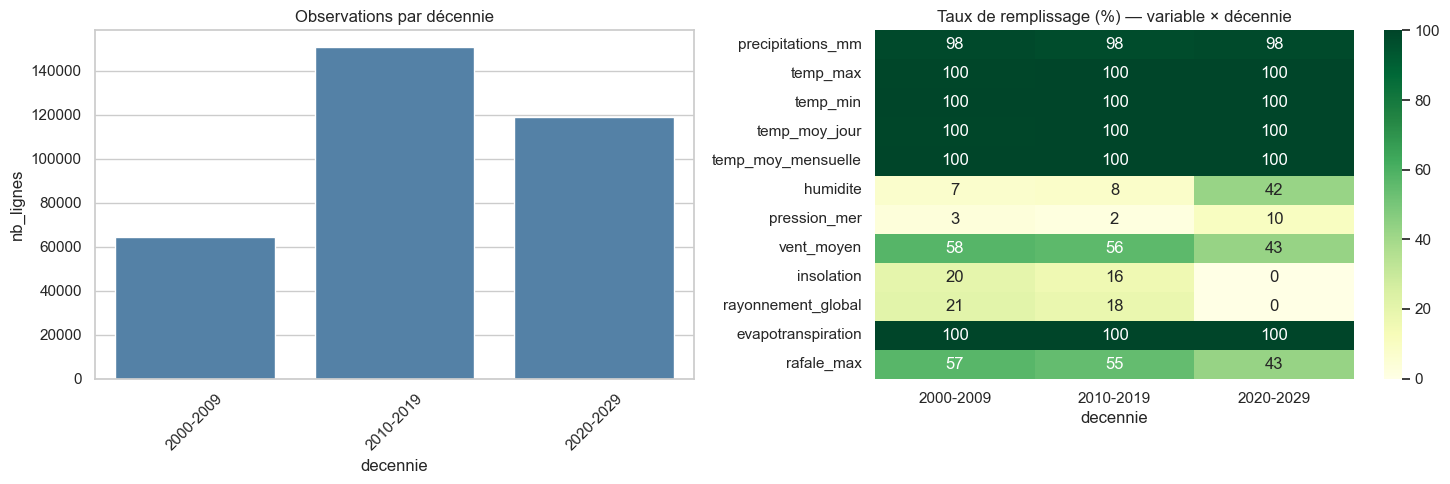

In [47]:
volume_dec = df.groupby("decennie", sort=True).agg(
    nb_lignes=("NUM_POSTE", "count"),
    nb_stations=("NUM_POSTE", "nunique"),
    nb_departements=("code_departement", "nunique"),
).reset_index()

remplissage_dec = (
    df.groupby("decennie")[METEO_COLS]
    .apply(lambda g: (g.notna().mean() * 100).round(1))
)

print("=== Volume par décennie ===")
display(volume_dec)
print("\n=== Taux de remplissage (%) par décennie ===")
display(remplissage_dec)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=volume_dec, x="decennie", y="nb_lignes", color="steelblue", ax=axes[0])
axes[0].set_title("Observations par décennie")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(
    remplissage_dec.T, annot=True, fmt=".0f", cmap="YlGn", vmin=0, vmax=100, ax=axes[1]
)
axes[1].set_title("Taux de remplissage (%) — variable × décennie")
plt.tight_layout()
plt.show()

### B.3 Vues agrégées département et région (dérivées de la source)

Moyenne des stations par département × mois — utile pour cartes et ML au niveau territorial.

In [48]:
df_dept = (
    df.groupby(
        ["code_departement", "nom_departement", "code_region", "nom_region", "annee", "mois", "date"],
        as_index=False,
    )[METEO_COLS]
    .mean()
)

df_region = (
    df_dept.groupby(["code_region", "nom_region", "annee", "mois", "date"], as_index=False)[METEO_COLS]
    .mean()
)

print(f"Niveau département : {len(df_dept):,} lignes")
print(f"Niveau région     : {len(df_region):,} lignes")
df_dept.head(3)

Niveau département : 24,852 lignes
Niveau région     : 3,612 lignes


,code_departement,nom_departement,code_region,nom_region,annee,mois,date,precipitations_mm,temp_max,temp_min,temp_moy_jour,temp_moy_mensuelle,humidite,pression_mer,vent_moyen,insolation,rayonnement_global,evapotranspiration,rafale_max
0,01,Ain,84,Auvergne-Rhône-Alpes,2001,1,2001-01-01,112.4,8.5,2.6,5.6,5.4,81.0,1014.7,3.4,2329.0,NaN,28.8,25.0
1,01,Ain,84,Auvergne-Rhône-Alpes,2001,2,2001-02-01,31.8,9.4,0.9,5.2,4.9,77.0,1020.5,3.5,6132.0,NaN,38.1,19.0
2,01,Ain,84,Auvergne-Rhône-Alpes,2001,3,2001-03-01,251.2,14.7,6.7,10.7,10.5,77.0,1008.9,3.3,5919.0,NaN,60.0,24.0


### B.4 Graphiques — séries temporelles

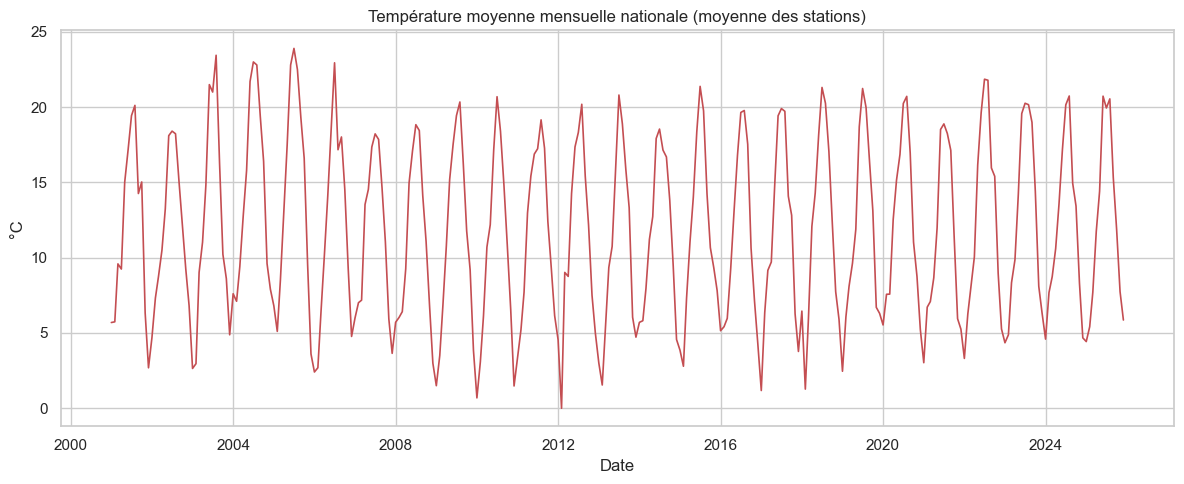

In [49]:
national = df.groupby("date")["temp_moy_mensuelle"].mean().reset_index(name="temp_moy")

fig, ax = plt.subplots()
ax.plot(national["date"], national["temp_moy"], linewidth=1.2, color="#c44e52")
ax.set_title("Température moyenne mensuelle nationale (moyenne des stations)")
ax.set_xlabel("Date")
ax.set_ylabel("°C")
plt.tight_layout()
plt.show()

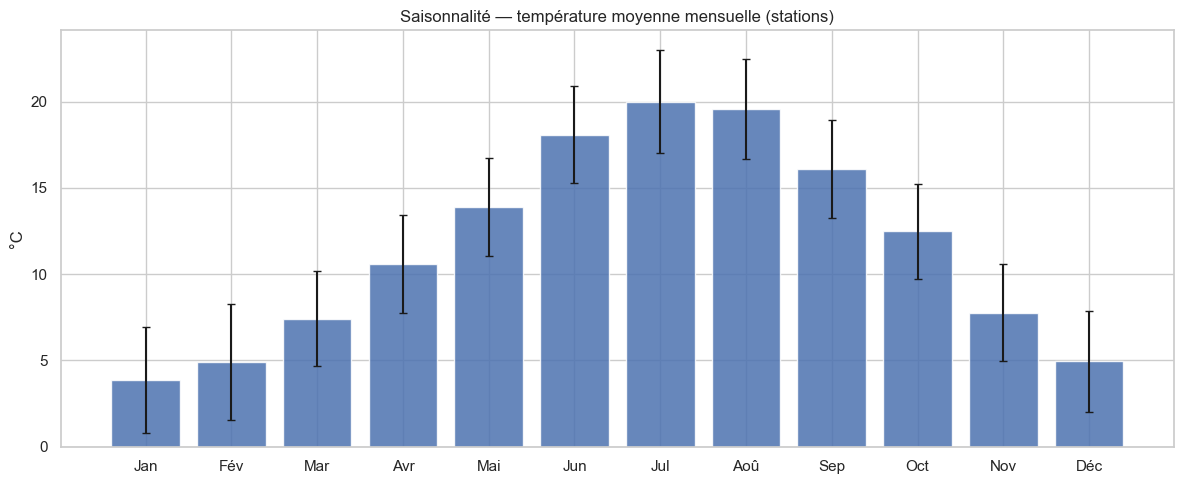

In [50]:
seasonal = df.groupby("mois")["temp_moy_mensuelle"].agg(["mean", "std"]).reset_index()
month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots()
ax.bar(seasonal["mois"], seasonal["mean"], yerr=seasonal["std"], capsize=3, color="#4c72b0", alpha=0.85)
ax.set_xticks(seasonal["mois"])
ax.set_xticklabels(month_labels)
ax.set_title("Saisonnalité — température moyenne mensuelle (stations)")
ax.set_ylabel("°C")
plt.tight_layout()
plt.show()

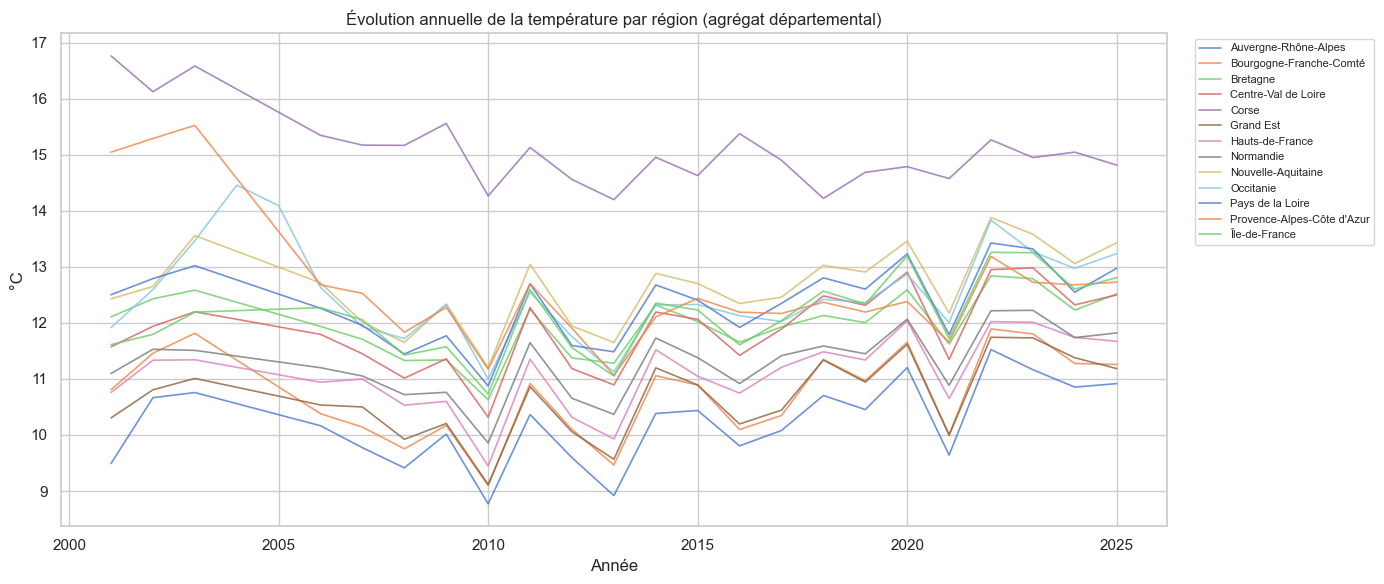

In [51]:
regional = df_dept.groupby(["nom_region", "annee"])["temp_moy_mensuelle"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for region, grp in regional.groupby("nom_region"):
    ax.plot(grp["annee"], grp["temp_moy_mensuelle"], label=region, linewidth=1.2, alpha=0.8)
ax.set_title("Évolution annuelle de la température par région (agrégat départemental)")
ax.set_xlabel("Année")
ax.set_ylabel("°C")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

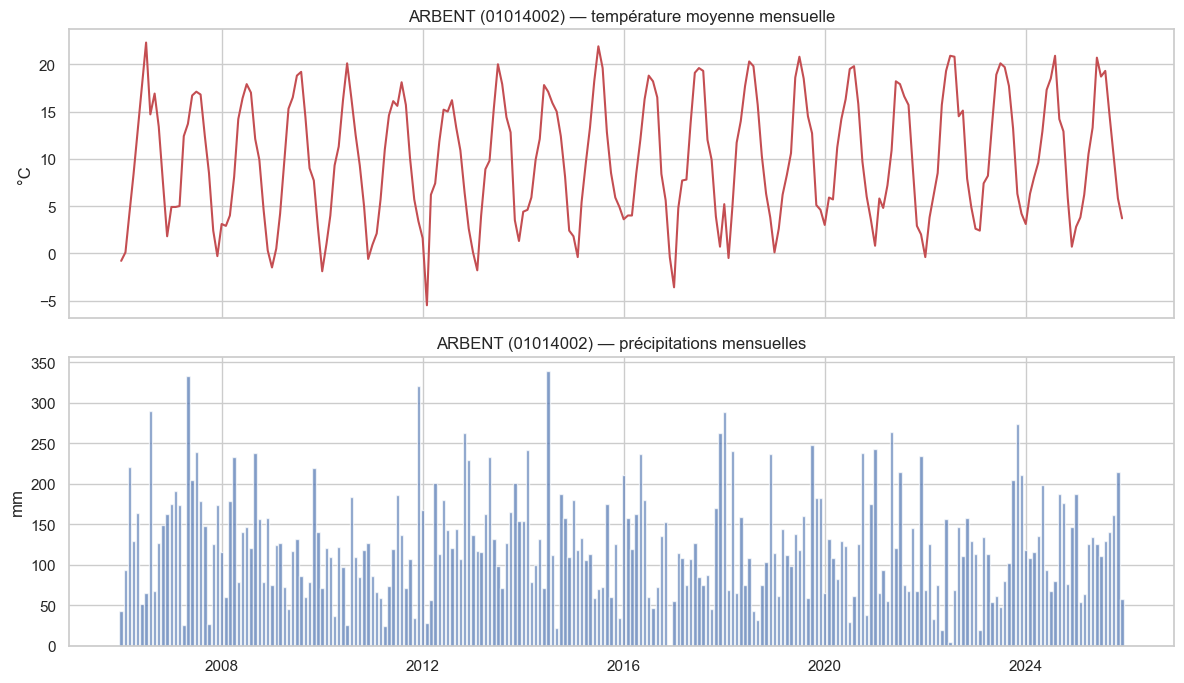

In [52]:
sample_poste = df["NUM_POSTE"].iloc[0]
sample = df[df["NUM_POSTE"] == sample_poste].copy()
label = f"{sample['nom_station'].iloc[0]} ({sample_poste})"

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(sample["date"], sample["temp_moy_mensuelle"], color="#c44e52")
axes[0].set_title(f"{label} — température moyenne mensuelle")
axes[0].set_ylabel("°C")
axes[1].bar(sample["date"], sample["precipitations_mm"], width=25, color="#4c72b0", alpha=0.7)
axes[1].set_title(f"{label} — précipitations mensuelles")
axes[1].set_ylabel("mm")
plt.tight_layout()
plt.show()

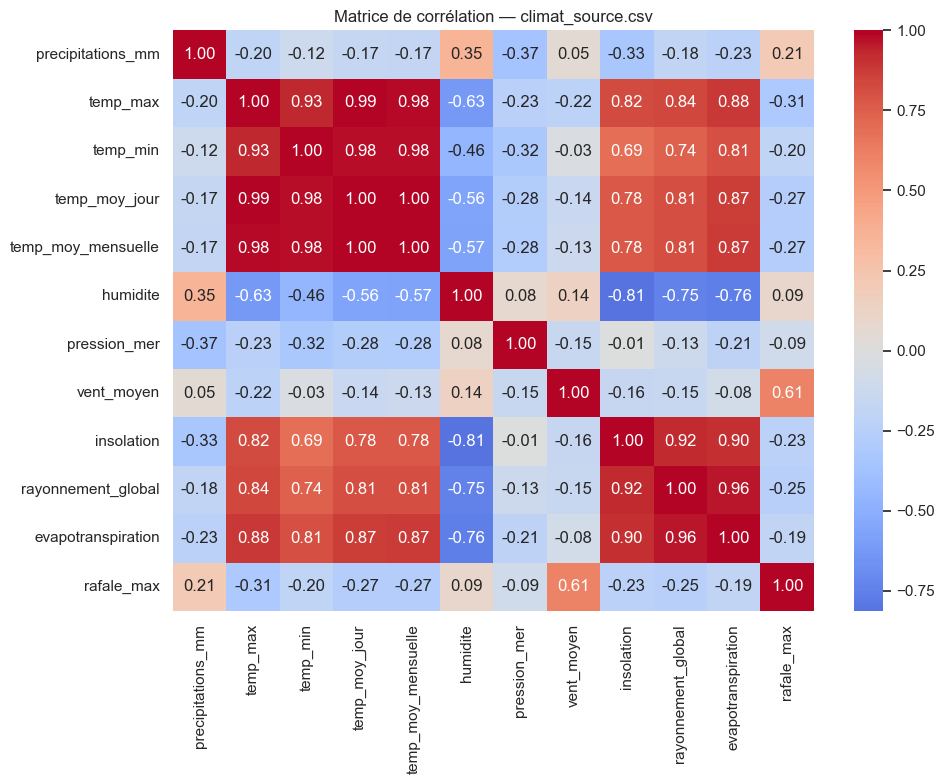

In [53]:
corr_cols = [c for c in METEO_COLS if df[c].notna().sum() > 100]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matrice de corrélation — climat_source.csv")
plt.tight_layout()
plt.show()

## Synthèse

| Élément | Valeur |
|---------|--------|
| **Source de vérité** | `src/data/processed/climat_source.csv` |
| Granularité | Station (`NUM_POSTE`) × mois |
| Filtres | Q0/Q1/Q9, année > 2000, 12 mois complets |
| Vues dérivées | `df_dept`, `df_region` (agrégations pour cartes / ML territorial) |
| Suite | `02_modelisation_ml.ipynb` consomme ce fichier |